Dataset from internet

In [1]:
from sklearn.datasets import load_wine

wine = load_wine()
print(wine.feature_names)


['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score

# Load dataset
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Random Forest
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Baseline accuracy
baseline_accuracy = accuracy_score(y_test, model.predict(X_test))
print("Baseline Accuracy:", baseline_accuracy)

# Permutation Feature Importance
result = permutation_importance(
    model, X_test, y_test,
    n_repeats=10,
    random_state=42
)

# Store results in DataFrame
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance Mean": result.importances_mean,
    "Importance Std": result.importances_std
}).sort_values(by="Importance Mean", ascending=False)

print("\nPermutation Feature Importance:")
print(importance_df)


Baseline Accuracy: 1.0

Permutation Feature Importance:
                         Feature  Importance Mean  Importance Std
12                       proline         0.069444        0.025610
6                     flavanoids         0.050000        0.020787
0                        alcohol         0.025000        0.014959
9                color_intensity         0.019444        0.021695
1                     malic_acid         0.000000        0.000000
2                            ash         0.000000        0.000000
3              alcalinity_of_ash         0.000000        0.000000
4                      magnesium         0.000000        0.000000
5                  total_phenols         0.000000        0.000000
7           nonflavanoid_phenols         0.000000        0.000000
8                proanthocyanins         0.000000        0.000000
10                           hue         0.000000        0.000000
11  od280/od315_of_diluted_wines         0.000000        0.000000


Cancer dataset from dataset.karunya.edu

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt


In [4]:
# Load dataset
df = pd.read_csv("Cancer.csv")

# Drop ID column (not useful for prediction)
df = df.drop("id", axis=1)

# Convert target column to numeric
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

# Separate features and target
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

print("Features:")
print(X.columns)


Features:
Index(['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean'],
      dtype='object')


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [6]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Baseline Accuracy
baseline_accuracy = accuracy_score(y_test, model.predict(X_test))
print("Baseline Accuracy:", baseline_accuracy)


Baseline Accuracy: 0.956140350877193


In [7]:
result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

# Store results
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance Mean": result.importances_mean,
    "Importance Std": result.importances_std
}).sort_values(by="Importance Mean", ascending=False)

print("\nPermutation Feature Importance:")
print(importance_df)



Permutation Feature Importance:
                  Feature  Importance Mean  Importance Std
7     concave points_mean     2.105263e-02        0.014783
1            texture_mean     2.105263e-02        0.011234
9  fractal_dimension_mean     7.017544e-03        0.003509
4         smoothness_mean     5.263158e-03        0.004297
8           symmetry_mean     5.263158e-03        0.004297
5        compactness_mean     3.508772e-03        0.004297
3               area_mean     2.631579e-03        0.007895
6          concavity_mean    -1.110223e-17        0.012405
2          perimeter_mean    -1.754386e-03        0.005263
0             radius_mean    -6.140351e-03        0.005617


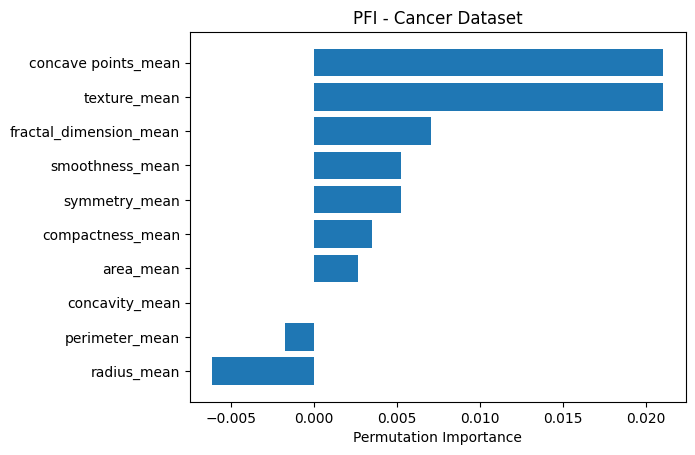

In [8]:
plt.figure()
plt.barh(importance_df["Feature"], importance_df["Importance Mean"])
plt.xlabel("Permutation Importance")
plt.title("PFI - Cancer Dataset")
plt.gca().invert_yaxis()
plt.show()
